Action Space Discrete(6)
Observation Space Discrete(500)


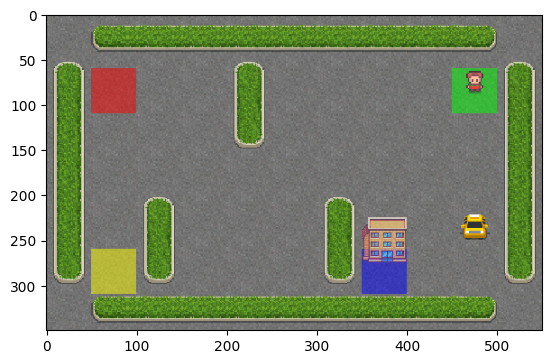

In [1]:
import gym
from PIL import Image
import matplotlib.pyplot as plt

env = gym.make("Taxi-v3", render_mode="rgb_array")

env.reset()
img = env.render()

print(f"Action Space {env.action_space}")
print(f"Observation Space {env.observation_space}")

plt.imshow(img)

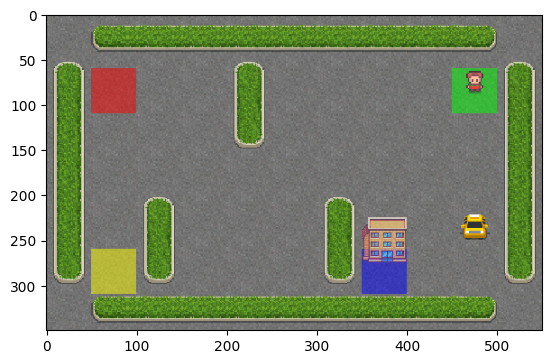

In [2]:
# taxi, taxi, passenger pickup, destination
initial_state = env.encode(2,3,2,0)

env.s = initial_state
plt.imshow(env.render())

In [3]:
env.P[initial_state]


{0: [(1.0, 368, -1, False)],
 1: [(1.0, 168, -1, False)],
 2: [(1.0, 288, -1, False)],
 3: [(1.0, 248, -1, False)],
 4: [(1.0, 268, -10, False)],
 5: [(1.0, 268, -10, False)]}

In [10]:
# Q table implementation

import numpy as np
import random
from IPython.display import clear_output, display
from time import sleep

q_table = np.zeros([env.observation_space.n, env.action_space.n])
# 2d array rows = state, columns = actions
q_table

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]], shape=(500, 6))

In [12]:
# Training q table

n_epochs = 10000
learning_rate = 0.1
epsilon = 0.1
df = 0.5

for train_time in range(n_epochs):

    state = env.reset()[0]
    epochs, penalties, reward, = 0, 0, 0
    done = False

    while not done:

        random_value = random.uniform(0, 1)
        # action is the index of the state table
        if random_value < epsilon:
            # exploration space
            action = env.action_space.sample()
        else:
            # exploitation space, find the max action value fro  current state
            action = np.argmax(q_table[state])

        next_state, reward, done, _, info = env.step(action) 

        old_q = q_table[state, action]
        next_max_q = np.max(q_table[next_state])

        new_value = (1 - learning_rate) * old_q + learning_rate * (reward + df * next_max_q)
        q_table[state, action] = new_value

        state = next_state
        epochs += 1

    if train_time % 100 == 0:
        clear_output(wait=True)
        print(f"Episode: {train_time}")

print("Training finished.\n")





Episode: 9900
Training finished.



KeyboardInterrupt: 

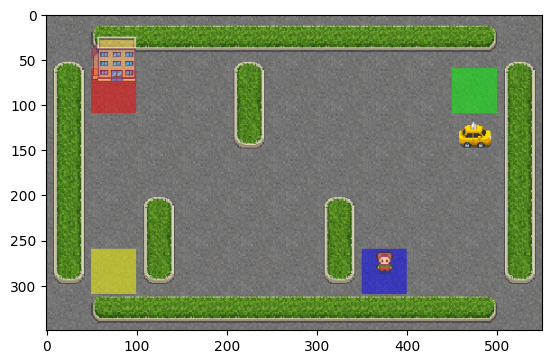

In [14]:


for trip in range(1,11):
    state = env.reset()[0]
    done = False
    epochs, penalties, reward = 0, 0, 0

    while not done:

        action = np.argmax(q_table[state])
        next_state, reward, done, _, info = env.step(action)

        display(plt.gcf())
        clear_output(wait=True)

        plt.imshow(env.render())
        sleep(.1)
        state = next_state
    print("1")
    sleep(1)